<a href="https://colab.research.google.com/github/patriciasandagorda/AST/blob/main/PRACTICA_AST_Clase_5_5_Skfore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div class="alert alert-block alert-info">
    <h1>Análisis de Series Temporales</h1>
    <h3>Clase 5 - Modelos de Ensambles</h3>
    <h3>Ejercicio 5_Anexo</h3>
        <p>Docentes: Rodrigo Del Rosso, Drago Braian, Sebastian Calcagno<p>
</div>

**Modelos Ensambles**  

**Objetivo del Ejercicio**: A traves del dataset disponible, el cual representa la usabilidad por hora del sistema de Bicicletas Publicas de la ciudad de Washington, D.C. entre 2011 y 2012. Debe elaborarse un modelo de ML utilizando un modelo de ensamblado, para predecir el número de usuarios dentro de las proximas 36 horas.  

Porque? Con esta información se puede planificar mejor la redistribución de Bicicletas.

Fuente de la documentación y el ejercicio: Forecasting time series with gradient LightGBM by Joaquín Amat Rodrigo and Javier Escobar Ortiz, available under a Attribution-NonCommercial-ShareAlike 4.0 International at https://www.cienciadedatos.net/documentos/py58-forecasting-time-series-with-lightgbm.html

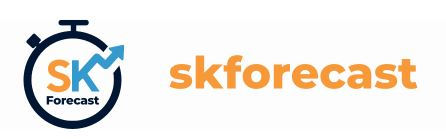

https://skforecast.org/0.16.0/index.html

In [ ]:
!pip install skforecast session_info

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 815.0/815.0 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.6/83.6 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.0/247.0 kB 19.4 MB/s eta 0:00:00


Carga de Librerías

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
pio.templates.default = "seaborn"
plt.style.use('seaborn-v0_8-darkgrid')
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.compose import make_column_selector
from skforecast.recursive import ForecasterRecursive
from skforecast.model_selection import TimeSeriesFold
from skforecast.model_selection import grid_search_forecaster
from skforecast.model_selection import bayesian_search_forecaster
from skforecast.model_selection import backtesting_forecaster
import warnings
warnings.filterwarnings("ignore")

# Carga y Procesamiento inicial del dataset

In [ ]:
url = 'https://raw.githubusercontent.com/braiandrago/AST/main/bike_sharing_dataset_clean.csv'

In [ ]:
bicicles = pd.read_csv(url,parse_dates=[1])
bicicles['date_time'] = pd.to_datetime(bicicles['date_time'], format='%Y-%m-%d %H:%M:%S')
bicicles = bicicles.set_index('date_time')
bicicles = bicicles.asfreq('h')
bicicles = bicicles.sort_index()
bicicles = bicicles.drop(columns=['workingday'])
bicicles.head()
print(bicicles.shape)
bicicles.head()

(17544, 10)


,holiday,weather,temp,atemp,hum,windspeed,users,month,hour,weekday
date_time,,,,,,,,,,
2011-01-01 00:00:00,0.0,clear,9.84,14.395,81.0,0.0,16.0,1,0,5
2011-01-01 01:00:00,0.0,clear,9.02,13.635,80.0,0.0,40.0,1,1,5
2011-01-01 02:00:00,0.0,clear,9.02,13.635,80.0,0.0,32.0,1,2,5
2011-01-01 03:00:00,0.0,clear,9.84,14.395,75.0,0.0,13.0,1,3,5
2011-01-01 04:00:00,0.0,clear,9.84,14.395,75.0,0.0,1.0,1,4,5


In [ ]:
import plotly.graph_objs as go
from plotly.subplots import make_subplots

# create a list of available columns
available_columns = bicicles.columns.tolist()

# create initial visible traces
visible = [True] * len(available_columns)

# create subplot
fig = make_subplots()

# add traces
for i, column in enumerate(available_columns):
    trace = go.Scatter(x=bicicles.index, y=bicicles[column], name=column, visible=visible[i])
    fig.add_trace(trace)

# update layout
fig.update_layout(
    updatemenus=[
        dict(
            type='dropdown',
            active=0,
            buttons=list(
                [
                    dict(label='All',
                         method='update',
                         args=[{'visible': [True] * len(available_columns)},
                               {'yaxis': {'title': 'Values'}}]),
                    dict(label='None',
                         method='update',
                         args=[{'visible': [False] * len(available_columns)},
                               {'yaxis': {'title': 'Values'}}])
                ] + [
                    dict(label=column,
                         method='update',
                         args=[{'visible': [column == col for col in available_columns]},
                               {'yaxis': {'title': column}}])
                    for column in available_columns
                ]
            )
        )
    ])

# update x-axis
fig.update_xaxes(
    tickmode='linear',
    tick0=bicicles.index[0],
    dtick='M1',
    tickformat='%Y-%m-%d')

# show plot
fig.show()

Dividimos en train, valid y test:

In [ ]:
end_train = '2012-03-31 23:59:00'
end_validation = '2012-08-31 23:59:00'
data_train = bicicles.loc[: end_train, :]
data_val   = bicicles.loc[end_train:end_validation, :]
data_test  = bicicles.loc[end_validation:, :]

In [ ]:
bicicles.loc[:end_train, 'partition'] = 'train'
bicicles.loc[end_train:end_validation, 'partition'] = 'validation'
bicicles.loc[end_validation:, 'partition'] = 'test'

fig = px.line(
    data_frame = bicicles.reset_index(),
    x      = 'date_time',
    y      = 'users',
    color  = 'partition',
    title  = 'Number of users',
    width  = 800,
    height = 450
)
fig.update_layout(
    width  = 800,
    height = 400,
    margin=dict(l=20, r=20, t=35, b=20),
    legend=dict(
        orientation="h",
        yanchor="top",
        y=1,
        xanchor="left",
        x=0.001
    )
)
fig.update_xaxes(rangeslider_visible=True)
fig.show()
data=bicicles.drop(columns='partition')

Estacionalidad

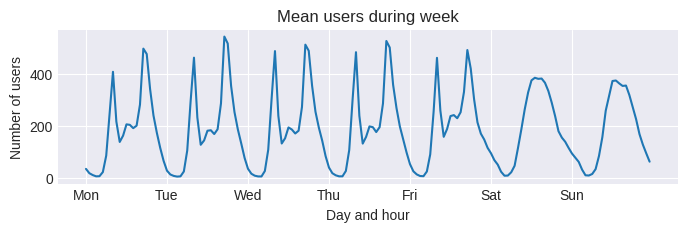

In [ ]:
fig, ax = plt.subplots(figsize=(8, 2))
mean_day_hour = data.groupby(["weekday", "hour"])["users"].mean()
mean_day_hour.plot(ax=ax)
ax.set(
    title="Mean users during week",
    xticks=[i * 24 for i in range(7)],
    xticklabels=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"],
    xlabel="Day and hour",
    ylabel="Number of users"
);

Diagramas de Autocorrelaciones:

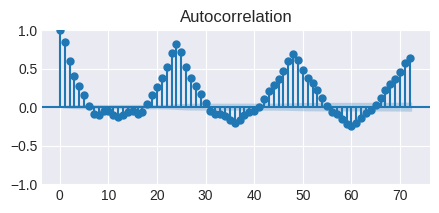

In [ ]:
fig, ax = plt.subplots(figsize=(5, 2))
plot_acf(data['users'], ax=ax, lags=72)
plt.show()

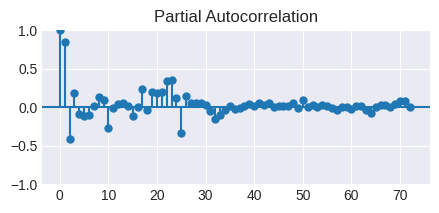

In [ ]:
fig, ax = plt.subplots(figsize=(5, 2))
plot_pacf(data['users'], ax=ax, lags=72, method='ywm')
plt.show()

Se observan fuertes correlaciones en lags pasados,los cuales podrías ser buenos predictores. Esto significa que conocer la cantidad de usuarios durante ciertos períodos en el pasado podría ser valioso para predecir la cantidad de usuarios en el futuro.

**Elaboración del Modelo**

1. Primero, se entrena un modelo autorregresivo utilizando valores pasados ​​(retrasos) de la variable de respuesta como predictores.  
2. Posteriormente se añaden variables exógenas al modelo y se evalúa la mejora en su desempeño.


Los modelos de aumento de gradiente tienen una gran cantidad de hiperparámetros, por lo que se utiliza una combinación de estrategia **bayesian_search** y **backtesting** para identificar la mejor configuración que brinde las predicciones más precisas.

In [ ]:
forecaster = ForecasterRecursive(
                 regressor = XGBRegressor(random_state=123),
                 lags = 24
             )

**Hyperparameter tuning:**  
Para evitar Overfitting, se realiza una búsqueda en la que cada combinación de hiperparámetros y retrasos se prueba de la siguiente manera:

-Entrene el modelo usando solo el conjunto de entrenamiento.

-El modelo se evalúa utilizando el conjunto de validación mediante backtesting.

-Se selecciona la combinación de hiperparámetros y retrasos que produce el error más bajo.

-Vuelva a entrenar el modelo utilizando la mejor combinación encontrada, esta vez utilizando tanto los datos de entrenamiento como los de validación.

In [ ]:
# Lags grid
lags_grid = [24, 48, 72]

# Regressor hyperparameters search space
def search_space(trial):
    search_space  = {
        'n_estimators'    : trial.suggest_int('n_estimators', 400, 1200, step=100),
        'max_depth'       : trial.suggest_int('max_depth', 3, 10, step=1),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 1),
        'subsample'       : trial.suggest_float('subsample', 0.1, 1),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.1, 1),
        'gamma'           : trial.suggest_float('gamma', 0, 1),
        'reg_alpha'       : trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda'      : trial.suggest_float('reg_lambda', 0, 1),
        'lags'            : trial.suggest_categorical('lags', lags_grid)
    }
    return search_space

# Folds
cv_searh = TimeSeriesFold(
                steps              = 36, #Define cuántos puntos de datos forman el conjunto de prueba en cada fold.
                initial_train_size = len(data_train), #El primer fold usa todo data_train como entrenamiento inicial
                refit              = False, #El modelo se entrena una sola vez al inicio con los set de train y luego se evalúa en cada fold sin reentrenarse.
            )

results_search, frozen_trial = bayesian_search_forecaster(
                                    forecaster    = forecaster,
                                    y             = data.loc[:end_validation, 'users'],
                                    search_space  = search_space,
                                    cv            = cv_searh,
                                    metric        = 'mean_absolute_error',
                                    n_trials      = 20,
                                    random_state  = 123,
                                    return_best   = True,
                                    n_jobs        = 'auto',
                                    verbose       = False,
                                    show_progress = True
                                )
best_params = results_search['params'].iat[0]
best_lags = results_search['lags'].iat[0]

  0%|          | 0/20 [00:00<?, ?it/s]

`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72] 
  Parameters: {'n_estimators': 1000, 'max_depth': 6, 'learning_rate': 0.06908111764347266, 'subsample': 0.4582398297973883, 'colsample_bytree': 0.7641958651588321, 'gamma': 0.18249173045349998, 'reg_alpha': 0.17545175614749253, 'reg_lambda': 0.5315513738418384}
  Backtesting metric: 77.00204181542857


In [ ]:
# Search results
# ==============================================================================
results_search.head(3)

,lags,params,mean_absolute_error,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,gamma,reg_alpha,reg_lambda
0,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'n_estimators': 1000, 'max_depth': 6, 'learni...",77.002042,1000.0,6.0,0.069081,0.458240,0.764196,0.182492,0.175452,0.531551
1,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'n_estimators': 800, 'max_depth': 8, 'learnin...",79.721582,800.0,8.0,0.160873,0.502052,0.643814,0.789708,0.389856,0.138057
2,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'n_estimators': 900, 'max_depth': 3, 'learnin...",81.792055,900.0,3.0,0.158713,0.724424,0.679900,0.798740,0.769680,0.246244


Dado que return_best = True, el objeto del pronosticador se actualizará con la mejor configuración encontrada y entrenada en todo el conjunto de datos. Esto significa que el modelo final obtenido de la búsqueda de cuadrícula tendrá la mejor combinación de retrasos e hiperparámetros que dieron como resultado la métrica de rendimiento más alta. Este modelo final se puede utilizar para futuras predicciones sobre nuevos datos.


**Baktesting - Time Series Split**
Una vez identificada la mejor combinación de hiperparámetros utilizando los datos de validación, se evalúa la capacidad predictiva del modelo cuando se aplica al conjunto de prueba. La función backtesting_forecaster se utiliza para simular el proceso de predicción cada 36 horas.
Esto ayudará a utilizar todo su potencial para analizar la capacidad predictiva del modelo.

In [ ]:
# Backtesting model
# ==============================================================================
cv = TimeSeriesFold(
        steps              = 36,
        initial_train_size = len(data[:end_validation]), #Usamos backtesting en train + valid para evaluar cómo el modelo generaliza en múltiples divisiones temporales.
        refit              = False,
)

metric, predictions = backtesting_forecaster(
                            forecaster    = forecaster,
                            y             = data['users'],
                            cv            = cv,
                            metric        = 'mean_absolute_error',
                            n_jobs        = 'auto',
                            verbose       = False,
                            show_progress = True
                       )
display(metric)
predictions.head()

  0%|          | 0/82 [00:00<?, ?it/s]

,mean_absolute_error
0,60.837274


,pred
2012-09-01 00:00:00,149.712006
2012-09-01 01:00:00,90.698189
2012-09-01 02:00:00,65.319656
2012-09-01 03:00:00,27.116501
2012-09-01 04:00:00,5.127841


Predicciones vs. Valores reales:

In [ ]:
# Plot predictions vs real value
# ======================================================================================
fig = go.Figure()
trace1 = go.Scatter(x=data_test.index, y=data_test['users'], name="test", mode="lines")
trace2 = go.Scatter(x=predictions.index, y=predictions['pred'], name="prediction", mode="lines")
fig.add_trace(trace1)
fig.add_trace(trace2)
fig.update_layout(
    title="Real value vs predicted in test data",
    xaxis_title="Date time",
    yaxis_title="Users",
    width=750,
    height=350,
    margin=dict(l=20, r=20, t=35, b=20),
    legend=dict(orientation="h", yanchor="top", y=1.1, xanchor="left", x=0.001)
)
fig.show()

**Variables Exogenas:**

Aunque las variables 'mes', 'día laborable', 'clima' y 'vacaciones' se almacenan como valores numéricos, en realidad son variables categóricas. Por lo tanto, es importante convertir su tipo de datos a categóricos para evitar que el modelo los interprete como características numéricas. Esto ayudará a garantizar que el modelo sea capaz de capturar con precisión las características y patrones únicos de estas variables.

La clase **OneHotEncoder** en scikit-learn se puede utilizar para transformar cualquier característica categórica con n valores posibles en n nuevas características binarias, donde una de ellas toma el valor 1 y todas las demás toman el valor 0.

**ColumnTransformers** en scikit-learn proporciona una forma poderosa de definir transformaciones y aplicarlas a características específicas. Al encapsular las transformaciones en un objeto ColumnTransformer, se puede pasar a un pronosticador utilizando el argumento transformador_exog.

In [ ]:
# Store categorical variables as category type
data["holiday"] = data["holiday"].astype("category")
data["weather"] = data["weather"].astype("category")
data["month"]   = data["month"].astype("category")
data["weekday"] = data["weekday"].astype("category")

In [ ]:
one_hot_encoder = make_column_transformer(
                      (
                          OneHotEncoder(sparse_output=False, drop='if_binary'),
                          make_column_selector(dtype_exclude=np.number),
                      ),
                      remainder="passthrough",
                      verbose_feature_names_out=False,
                  ).set_output(transform="pandas")

In [ ]:
forecaster = ForecasterRecursive(
                 regressor        = XGBRegressor(random_state=123),
                 lags             = 24,
                 transformer_exog = one_hot_encoder
             )

In [ ]:
# View Training Matrix
exog_features = ['weather', 'month', 'weekday', 'hour', 'holiday',
                 'temp', 'atemp', 'hum', 'windspeed']

X_train, y_train = forecaster.create_train_X_y(
                        y = data.loc[:end_validation, 'users'],
                        exog = data.loc[:end_validation, exog_features]
                   )
X_train.head(3)

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,...,weekday_3,weekday_4,weekday_5,weekday_6,holiday_1.0,hour,temp,atemp,hum,windspeed
date_time,,,,,,,,,,,,,,,,,,,,,
2011-01-02 00:00:00,39.0,28.0,34.0,36.0,37.0,35.0,67.0,93.0,110.0,106.0,...,0.0,0.0,0.0,1.0,0.0,0.0,18.86,22.725,88.0,19.9995
2011-01-02 01:00:00,17.0,39.0,28.0,34.0,36.0,37.0,35.0,67.0,93.0,110.0,...,0.0,0.0,0.0,1.0,0.0,1.0,18.04,21.970,94.0,16.9979
2011-01-02 02:00:00,17.0,17.0,39.0,28.0,34.0,36.0,37.0,35.0,67.0,93.0,...,0.0,0.0,0.0,1.0,0.0,2.0,17.22,21.210,100.0,19.0012


Hiperparametrizacion:

In [ ]:
# Lags grid
lags_grid = [48, 72]

# Regressor hyperparameters search space
def search_space(trial):
    search_space  = {
        'n_estimators'    : trial.suggest_int('n_estimators', 400, 1200, step=100),
        'max_depth'       : trial.suggest_int('max_depth', 3, 10, step=1),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 1),
        'subsample'       : trial.suggest_float('subsample', 0.1, 1),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.1, 1),
        'gamma'           : trial.suggest_float('gamma', 0, 1),
        'reg_alpha'       : trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda'      : trial.suggest_float('reg_lambda', 0, 1),
        'lags'            : trial.suggest_categorical('lags', lags_grid)
    }
    return search_space

# Folds
cv_searh = TimeSeriesFold(
                steps              = 36,
                initial_train_size = len(data_train),
                refit              = False,
            )

results_search, frozen_trial = bayesian_search_forecaster(
                                    forecaster    = forecaster,
                                    y             = data.loc[:end_validation, 'users'],
                                    exog          = data.loc[:end_validation, exog_features],
                                    search_space  = search_space,
                                    cv            = cv_searh,
                                    metric        = 'mean_absolute_error',
                                    n_trials      = 20,
                                    random_state  = 123,
                                    return_best   = True,
                                    n_jobs        = 'auto',
                                    verbose       = False,
                                    show_progress = True
                                )
best_params = results_search['params'].iat[0]
best_lags = results_search['lags'].iat[0]

  0%|          | 0/20 [00:00<?, ?it/s]

`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48] 
  Parameters: {'n_estimators': 1100, 'max_depth': 4, 'learning_rate': 0.11624321888584366, 'subsample': 0.8902413679425464, 'colsample_bytree': 0.585603166216034, 'gamma': 0.69974302890735, 'reg_alpha': 0.6866348092863803, 'reg_lambda': 0.8085069947605524}
  Backtesting metric: 62.060976244798354


In [ ]:
# Backtesting model with exogenous variables on test data
# ==============================================================================
metric, predictions = backtesting_forecaster(
                            forecaster    = forecaster,
                            y             = data['users'],
                            exog          = data[exog_features],
                            cv            = cv,
                            metric        = 'mean_absolute_error',
                            n_jobs        = 'auto',
                            verbose       = False,
                            show_progress = True
                       )
display(metric)
predictions.head()

  0%|          | 0/82 [00:00<?, ?it/s]

,mean_absolute_error
0,49.634824


,pred
2012-09-01 00:00:00,134.331238
2012-09-01 01:00:00,91.651634
2012-09-01 02:00:00,55.017765
2012-09-01 03:00:00,30.717978
2012-09-01 04:00:00,6.158780


In [ ]:
# Extract feature importances
importance = forecaster.get_feature_importances()
importance

,feature,importance
23,lag_24,0.204721
0,lag_1,0.170478
22,lag_23,0.106879
71,hour,0.095241
50,weather_rain,0.045367
...,...,...
51,month_1,0.000532
62,month_12,0.000529
53,month_3,0.000510
61,month_11,0.000493
